# Module 5: Dashboard Foundations

**Unit C · Week 5** · Track 2 — Visualization, Analytic Hubs & Responsible AI

A dashboard's chart-and-filter logic is worth proving out in a notebook before it goes into an app. This notebook builds the exact aggregation the app's callback will run; the app itself (Streamlit and Shiny versions) lives in `apps/` at the repo root and is run outside Jupyter.

## Learning objectives

- **Foundational** _Understand_ — Explain what distinguishes an analytic hub from a static report; sketch a basic architecture and audience-persona wireframe.
- **Intermediate** _Apply (started)_ — Wire a single chart and a single filter into a minimal working app.

## Setup

This notebook reads `../../data/processed/track2_dataset.csv`, built by
`data/make_sample_data.py`. It is **synthetic** data shaped like the real
NISR/HDX handoff described in the course site's Chapter 3 — swap in a real
extract by re-pointing the path below once you have one. See
`data/README.md` for where to get real data and exactly what to rename.


In [1]:
import pandas as pd

DATA_PATH = "../../data/processed/track2_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"{len(df):,} rows · {df['district'].nunique()} districts · "
      f"{df['date'].min().date()} to {df['date'].max().date()}")
df.head()

240 rows · 10 districts · 2023-01-01 to 2024-12-01


,date,province,district,district_pcode,indicator,value,feature_1,feature_2,outcome
0,2023-01-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,39.37,82.01,19.22,1
1,2023-02-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,45.24,49.99,17.62,1
2,2023-03-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,41.16,46.66,19.93,0
3,2023-04-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,42.91,49.17,20.35,0
4,2023-05-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,42.05,51.04,20.35,0


### The filter logic the app's callback will run

Given a province, return the filtered frame the chart draws from — this is the function `apps/streamlit_app.py` calls on every dropdown change.

<Axes: title={'center': 'Preview: Kigali City'}, xlabel='date'>

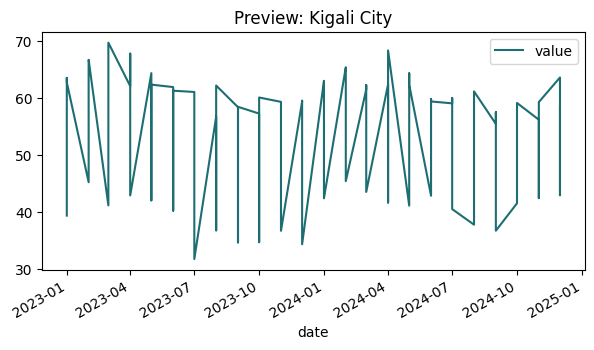

In [2]:
def filter_by_province(frame, province):
    return frame[frame["province"] == province].sort_values("date")

sample = filter_by_province(df, df["province"].iloc[0])
sample.plot(x="date", y="value", figsize=(7, 3.5), color="#1D6E73",
            title=f"Preview: {df['province'].iloc[0]}")

### The app

```python
# apps/streamlit_app.py  (excerpt — full file at the repo root)
import streamlit as st
import pandas as pd

st.set_page_config(page_title="Rwanda Regional Hub", layout="wide")
df = pd.read_csv("data/processed/track2_dataset.csv")

province = st.sidebar.selectbox("Province", sorted(df["province"].unique()))
filtered = df[df["province"] == province]

st.title("Regional Analytic Hub, Prototype")
st.line_chart(filtered, x="date", y="value")
```

Run with `streamlit run apps/streamlit_app.py` from the repo root.

## Your turn

Design brief: a one-page wireframe plus architecture sketch for a regional analytic hub, plus a minimal one-filter, one-chart working prototype. Run `streamlit run apps/streamlit_app.py` or `Rscript -e "shiny::runApp('apps/shiny_app.R')"` from the repo root to see the finished version.

**Formative assessment.** Design brief / structured worksheet, checklist-graded.